In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.optimizers import Adam
from keras.applications import EfficientNetB7
from keras.callbacks import ReduceLROnPlateau
from keras.utils import image_dataset_from_directory
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report
import keras

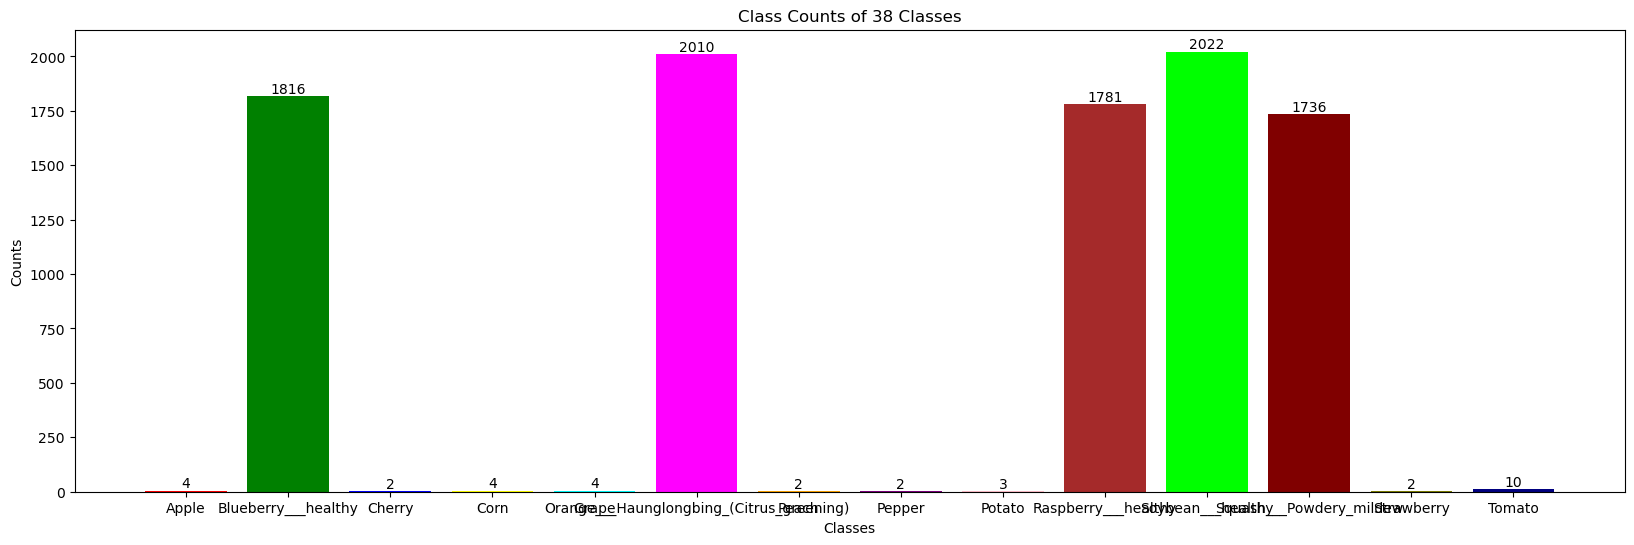

In [3]:
''' Block to visualize class frequencies before oversampling and undersampling '''
data_path = 'plantkaggle/two_stage/train'
classes = os.listdir(data_path) # names of folders are the names of classes
class_counts = [len(os.listdir(data_path + '/' + x)) for x in classes] # length of respective classes is the count of images available for the respective class
#print(class_counts)
plt.figure(figsize=(20, 6))
bars = plt.bar(classes, class_counts, color = [
    "#FF0000", "#008000", "#0000FF", "#FFFF00", "#00FFFF", "#FF00FF", "#FFA500",
    "#800080", "#FFC0CB", "#A52A2A", "#00FF00", "#800000", "#808000", "#000080"
]) # 38 random colors chosen for better visualisation
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts of 38 Classes')
# Code to display count of each class on top of respective bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height, 
        f'{height}', 
        ha='center', 
        va='bottom'
    )

In [5]:
val_path = "plantkaggle/two_stage/valid"
train_path = "plantkaggle/two_stage/train"
img_size =(256,256)
batch_size = 32
train_dataset = image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=123
)
class_names = train_dataset.class_names
val_dataset = image_dataset_from_directory(
    val_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=42
)

Found 70295 files belonging to 14 classes.
Found 17572 files belonging to 14 classes.


In [9]:
base_model = keras.applications.EfficientNetB3(
    input_shape=(256, 256, 3), 
    include_top=False,             
    weights='imagenet',
    pooling='max'
) 

for layer in base_model.layers:
    layer.trainable = False

# Build model
inputs = base_model.input
x = BatchNormalization()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Flatten()(x)
outputs = Dense(38, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
ep = 10
history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    epochs=ep)
                    
import tensorflow as tf
tf.saved_model.save(model, 'two_stage')

Epoch 1/10
2197/2197 [==============================] - 483s 217ms/step - loss: 0.2146 - accuracy: 0.9365 - val_loss: 0.0586 - val_accuracy: 0.9829
Epoch 2/10
2197/2197 [==============================] - 474s 216ms/step - loss: 0.1098 - accuracy: 0.9697 - val_loss: 0.0683 - val_accuracy: 0.9817
Epoch 3/10
2197/2197 [==============================] - 473s 215ms/step - loss: 0.0894 - accuracy: 0.9756 - val_loss: 0.0433 - val_accuracy: 0.9873
Epoch 4/10
2197/2197 [==============================] - 474s 216ms/step - loss: 0.0749 - accuracy: 0.9804 - val_loss: 0.0463 - val_accuracy: 0.9896
Epoch 5/10
2197/2197 [==============================] - 473s 215ms/step - loss: 0.0695 - accuracy: 0.9827 - val_loss: 0.0481 - val_accuracy: 0.9890
Epoch 6/10
2197/2197 [==============================] - 474s 216ms/step - loss: 0.0577 - accuracy: 0.9851 - val_loss: 0.0351 - val_accuracy: 0.9935
Epoch 7/10
2197/2197 [==============================] - 474s 216ms/step - loss: 0.0584 - accuracy: 0.9863 - val_

INFO:tensorflow:Assets written to: two_stage\assets


INFO:tensorflow:Assets written to: two_stage\assets


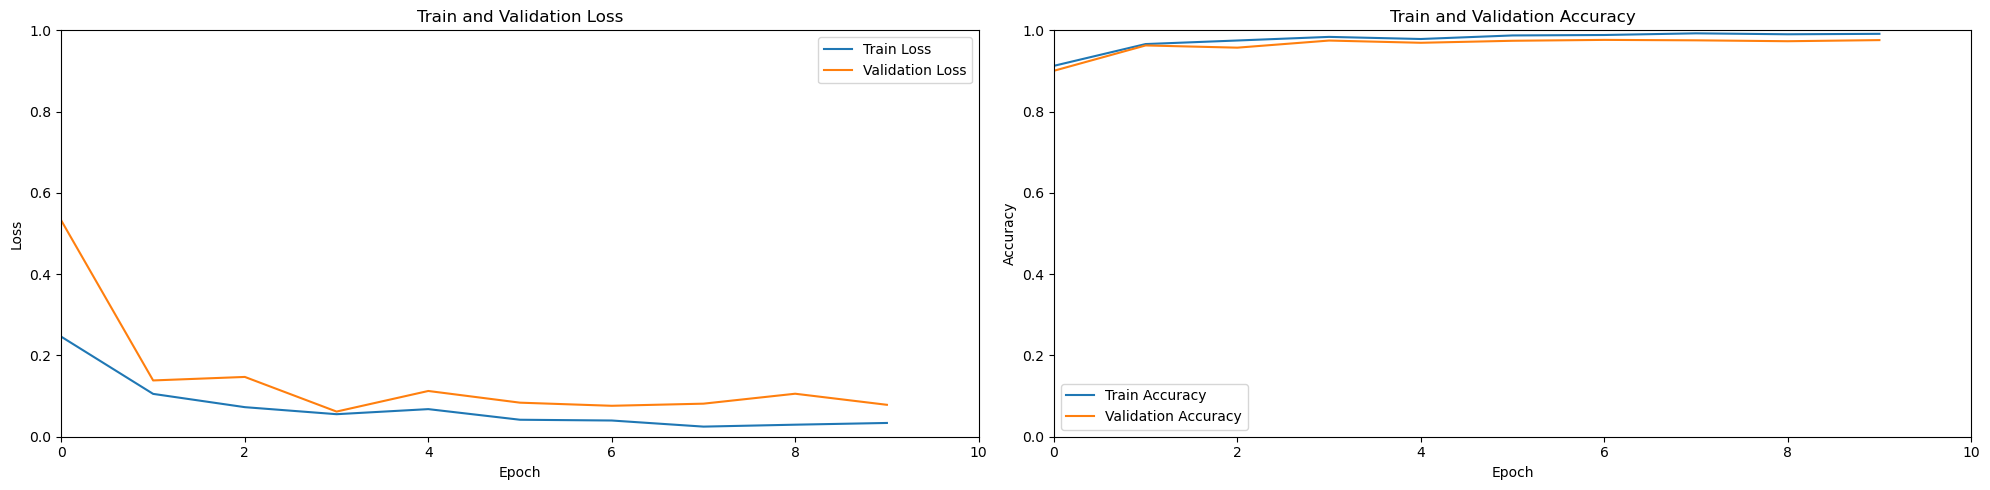

In [24]:
plt.figure(figsize = (20,5))
plt.subplot(1,2,1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlim(0, 10)
plt.ylim(0.0,1.0)
plt.legend()

plt.subplot(1,2,2)
plt.title("Train and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlim(0, 10)
plt.ylim(0.0,1.0)
plt.legend()
plt.tight_layout()

In [5]:
from keras import layers
from keras.applications import EfficientNetB5
import tensorflow as tf
def build_model():
    
    # Load the EfficientNetB5 base model with pre-trained ImageNet weights
    base_model = EfficientNetB5(
        input_shape=(256, 256, 3), 
        include_top=False, 
        weights='imagenet'
    )

    # Freeze the base model layers
    for layer in base_model.layers:
        layer.trainable = False

    # Create the model
    inputs = base_model.input
    x = base_model.output

    # Add additional Conv2D layers
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Flatten the feature maps
    x = layers.Flatten()(x)

    # Add Dense layers
    x = layers.Dense(1024, activation='relu')(x)
    #x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    #x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)

    # Output layer
    outputs = layers.Dense(10, activation='softmax')(x)

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), 
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

    # Print the model summary
    #model.summary()
    return model


series = ['Tomato']
histories = {}
models = {}
for i in series:
    val_path = "plantkaggle/two_stage/valid/"+i
    train_path = "plantkaggle/two_stage/train/"+i
    try:
        os.mkdir(i)
    except:
        pass
    img_size =(256,256)
    batch_size = 32
    train_dataset = image_dataset_from_directory(
        train_path,
        image_size=img_size,
        batch_size=batch_size,
        seed=123
    )
    class_names = train_dataset.class_names
    val_dataset = image_dataset_from_directory(
        val_path,
        image_size=img_size,
        batch_size=batch_size,
        seed=42
    )
    model = build_model()
    ep = 10
    history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    epochs=ep)
    histories[i] = history
    models[i] = model
   
    tf.saved_model.save(model, i)

Found 18345 files belonging to 10 classes.
Found 4585 files belonging to 10 classes.
Epoch 1/10
574/574 [==============================] - 252s 424ms/step - loss: 0.6878 - accuracy: 0.7604 - val_loss: 0.8325 - val_accuracy: 0.7381
Epoch 2/10
574/574 [==============================] - 243s 424ms/step - loss: 0.3450 - accuracy: 0.8847 - val_loss: 0.2906 - val_accuracy: 0.9095
Epoch 3/10
574/574 [==============================] - 244s 425ms/step - loss: 0.2467 - accuracy: 0.9171 - val_loss: 0.3424 - val_accuracy: 0.8888
Epoch 4/10
574/574 [==============================] - 244s 426ms/step - loss: 0.2052 - accuracy: 0.9328 - val_loss: 0.2387 - val_accuracy: 0.9237
Epoch 5/10
574/574 [==============================] - 244s 426ms/step - loss: 0.1688 - accuracy: 0.9452 - val_loss: 0.2293 - val_accuracy: 0.9322
Epoch 6/10
574/574 [==============================] - 244s 426ms/step - loss: 0.1449 - accuracy: 0.9540 - val_loss: 0.3118 - val_accuracy: 0.9152
Epoch 7/10
574/574 [===================

INFO:tensorflow:Assets written to: Tomato\assets


INFO:tensorflow:Assets written to: Tomato\assets


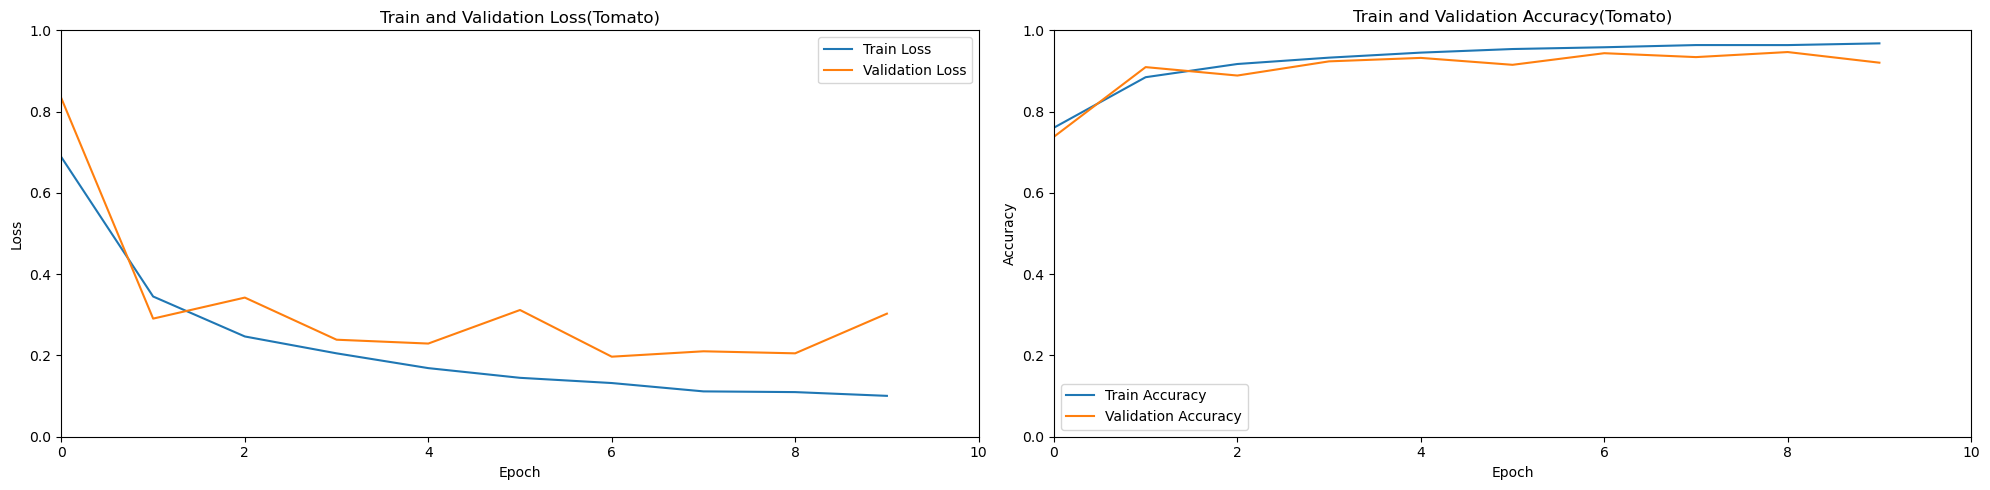

In [6]:
def plot(name, history):    
    plt.figure(figsize = (20,5))
    plt.subplot(1,2,1)
    plt.title("Train and Validation Loss("+name+')')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.plot(history.history['loss'],label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.xlim(0, 10)
    plt.ylim(0.0,1.0)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title("Train and Validation Accuracy("+name+')')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.plot(history.history['accuracy'], label="Train Accuracy")
    plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
    plt.xlim(0, 10)
    plt.ylim(0.0,1.0)
    plt.legend()
    plt.tight_layout()
for history in histories:
    plot(history, histories[history])

In [21]:
import pickle
with open('histories.pkl', 'wb') as file:
    pickle.dump(histories, file)

with open('models.pkl', 'wb') as file:
    pickle.dump(models, file)

INFO:tensorflow:Assets written to: ram://41f5d8e8-ddb0-4696-afc3-7a24bd7b2b03/assets


INFO:tensorflow:Assets written to: ram://41f5d8e8-ddb0-4696-afc3-7a24bd7b2b03/assets


TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [22]:
from keras import layers
from keras.applications import EfficientNetB5
def build_model():
    
    # Load the EfficientNetB5 base model with pre-trained ImageNet weights
    base_model = EfficientNetB5(
        input_shape=(256, 256, 3), 
        include_top=False, 
        weights='imagenet'
    )

    # Freeze the base model layers
    for layer in base_model.layers:
        layer.trainable = False

    # Create the model
    inputs = base_model.input
    x = base_model.output

    # Add additional Conv2D layers
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Flatten the feature maps
    x = layers.Flatten()(x)

    # Add Dense layers
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)

    # Output layer
    outputs = layers.Dense(8, activation='softmax')(x)

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), 
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

    # Print the model summary
    #model.summary()
    return model


series = ['Grape', 'Peach', 'Pepper', 'Potato', 'Strawberry', 'Tomato']
for i in series:
    val_path = "plantkaggle/two_stage/valid/"+i
    train_path = "plantkaggle/two_stage/train/"+i
    try:
        os.mkdir(i)
    except:
        pass
    img_size =(256,256)
    batch_size = 32
    train_dataset = image_dataset_from_directory(
        train_path,
        image_size=img_size,
        batch_size=batch_size,
        seed=123
    )
    class_names = train_dataset.class_names
    val_dataset = image_dataset_from_directory(
        val_path,
        image_size=img_size,
        batch_size=batch_size,
        seed=42
    )
    model = build_model()
    ep = 10
    history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    epochs=ep)
    histories[i] = history
    models[i] = model
    tf.saved_model.save(model, i)

Found 7222 files belonging to 4 classes.
Found 1805 files belonging to 4 classes.
Epoch 1/10


ResourceExhaustedError: Graph execution error:

Detected at node 'model_12/block2a_expand_conv/Conv2D' defined at (most recent call last):
    File "c:\Users\sreek\anaconda3\envs\envname\lib\runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\sreek\anaconda3\envs\envname\lib\runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "c:\Users\sreek\anaconda3\envs\envname\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "c:\Users\sreek\anaconda3\envs\envname\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Users\sreek\anaconda3\envs\envname\lib\site-packages\ipykernel\kernelapp.py", line 701, in start
      self.io_loop.start()
    File "c:\Users\sreek\anaconda3\envs\envname\lib\site-packages\tornado\platform\asyncio.py", line 205, in start
      self.asyncio_loop.run_forever()
    File "c:\Users\s

In [ ]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score
import tensorflow as tf

test_path = 'plant_disease_data/valid'

test_dataset = image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=42
)

labels = []
predictions = []
for x,y in test_dataset:
    labels.append(list(y.numpy().astype("uint8")))
    predictions.append(tf.argmax(model.predict(x),1).numpy().astype("uint8"))
import itertools
predictions = list(itertools.chain.from_iterable(predictions))
labels = list(itertools.chain.from_iterable(labels))
print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))
print('F1 score:', f1_score(labels, predictions, average='micro'))

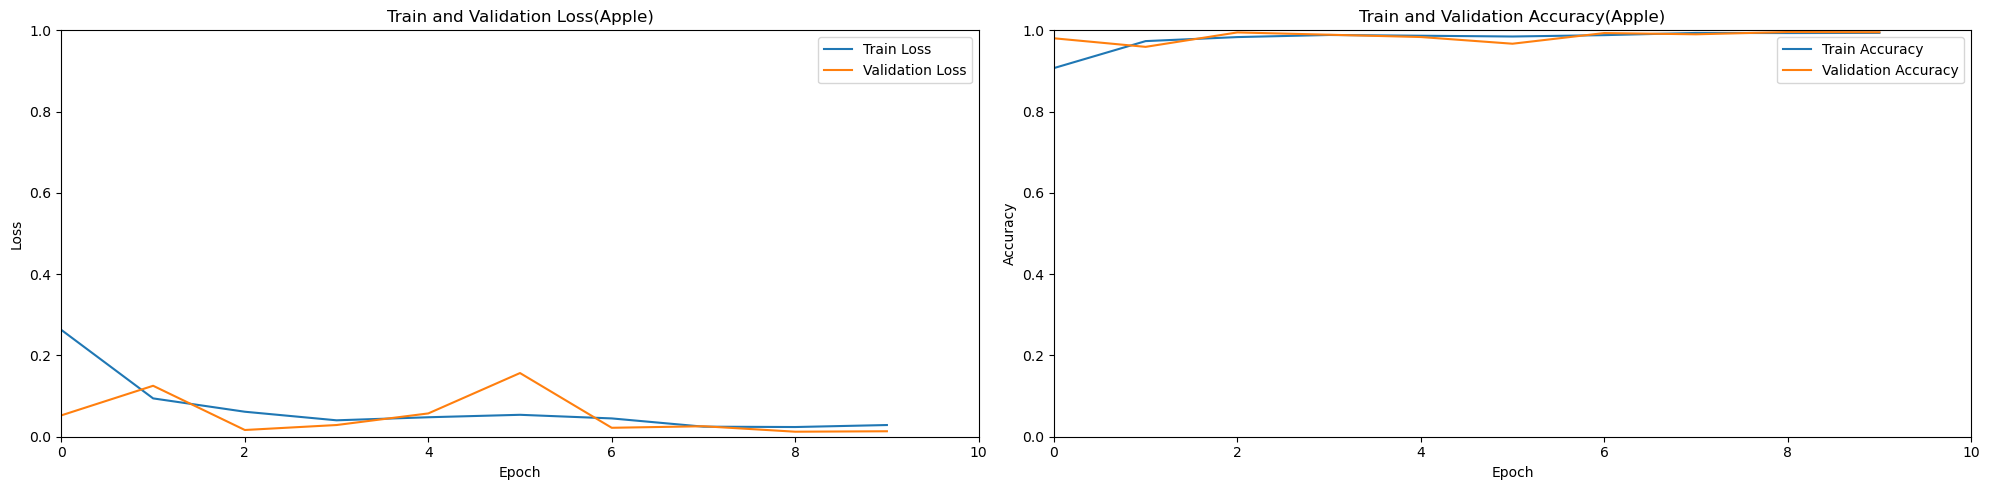

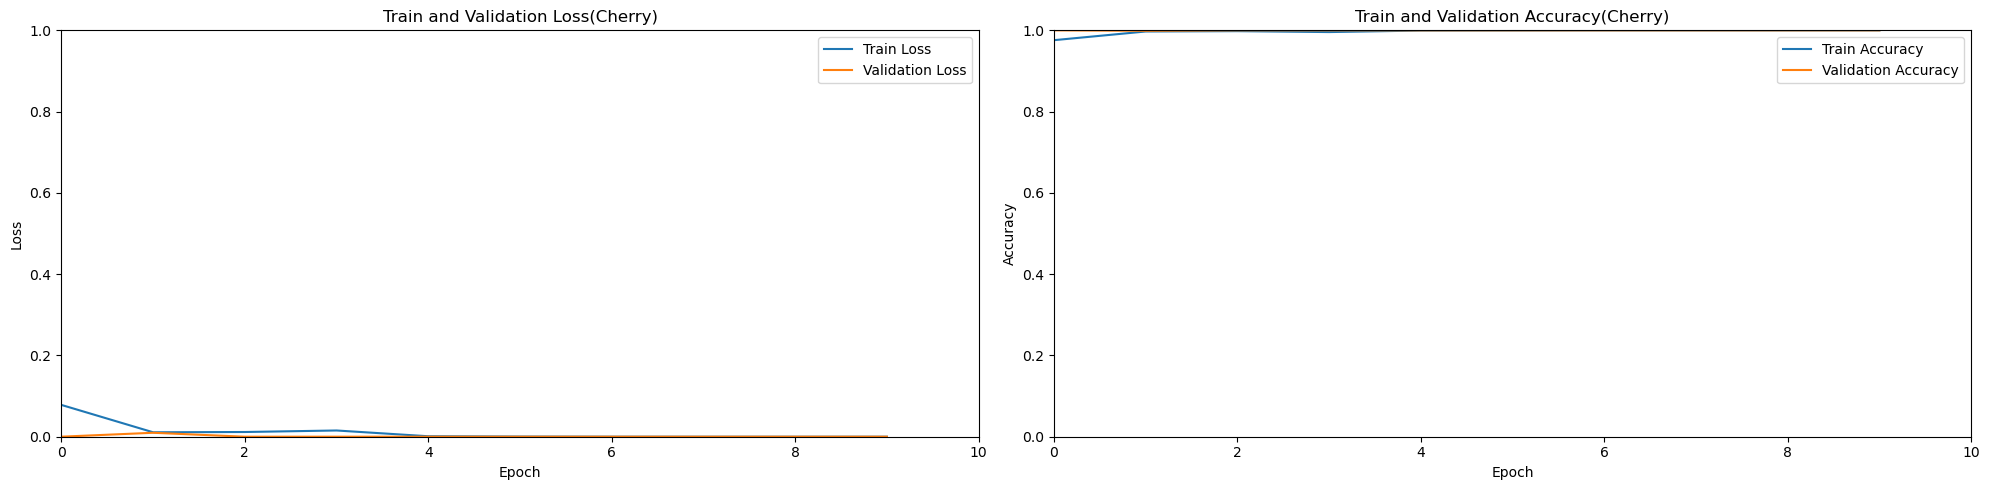

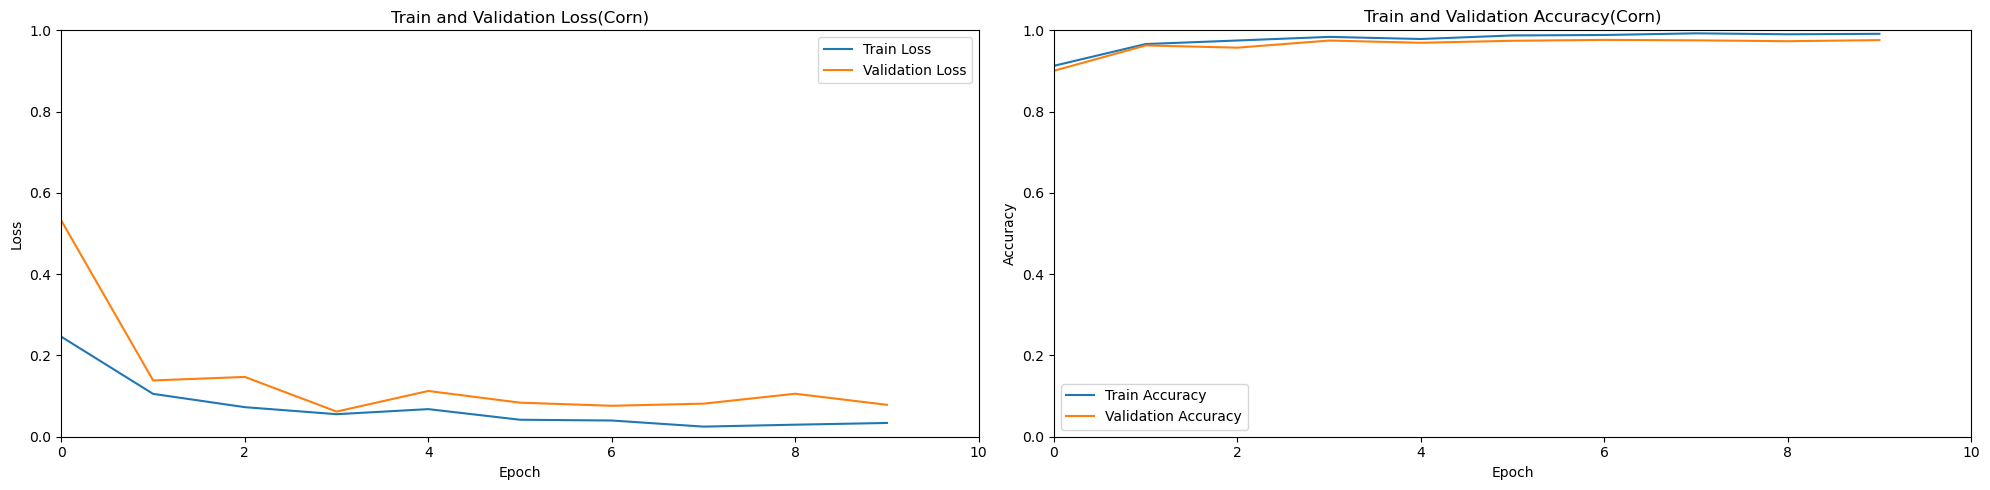

In [31]:
def plot(name, history):    
    plt.figure(figsize = (20,5))
    plt.subplot(1,2,1)
    plt.title("Train and Validation Loss("+name+')')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.plot(history.history['loss'],label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.xlim(0, 10)
    plt.ylim(0.0,1.0)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title("Train and Validation Accuracy("+name+')')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.plot(history.history['accuracy'], label="Train Accuracy")
    plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
    plt.xlim(0, 10)
    plt.ylim(0.0,1.0)
    plt.legend()
    plt.tight_layout()
for history in histories:
    plot(history, histories[history])

In [ ]:
import sklearn
plt.figure(figsize= (30,10))
cm = confusion_matrix(labels, predictions)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1,39)))
fig, ax = plt.subplots(figsize=(30,30))
disp.plot(ax=ax,colorbar= False,cmap = 'YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()